### MPNN scores


In [1]:

import numpy as np
import pandas as pd

import scipy.stats
from scipy.stats import spearmanr, pearsonr

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from plot_utils import annotate_ax_with_correlations as annotate_facet_with_correlations


In [2]:
final_seqs = pd.read_csv("../rosetta/screening_data/ordinal_Oct22_sequences_as_variant.csv")
final_seqs

,parent,variant,sequence_aa_trim
0,1VH,A15S.F152L.N198K,QHTYPAQLMRFGTSARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
1,1VH,K227E,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
2,1VH,P6R.S60G.G86D,QHTYRAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
3,1VH,A24V.N189D,QHTYPAQLMRFGTAARAEHMTIVAAIHALDADEADAIVMDIVPDGE...
4,1VH,T110S.M258I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
...,...,...,...
1321,3VRL,I219T.T238I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...
1322,3VRL,D41E.K88I.D164V,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMEIVPDGE...
1323,1VH,X1M,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...
1324,2L,X1M,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...


In [3]:
mpnn_rosetta_scores = pd.read_csv("../mpnn/outputs/mpnn_rosetta_struct_output_parsed.txt", 
                                  header=None, names=["seq", "mean", "std"])
mpnn_alphafold_scores = pd.read_csv("../mpnn/outputs/mpnn_alphafold_struct_output_parsed.txt", 
                                  header=None, names=["seq", "mean", "std"])

In [4]:
len(mpnn_alphafold_scores)

1327

In [5]:
# first sequence is the structure itself so drop it
final_seqs["mpnn_rosetta_score"] = mpnn_rosetta_scores.drop(index=0).reset_index()["mean"]
final_seqs["mpnn_alphafold_score"] = mpnn_alphafold_scores.drop(index=0).reset_index()["mean"]

In [6]:
final_dca = pd.read_csv("../output/ordinal_Oct22_sequences_with_dca_score.csv")

In [7]:
final_seqs_noparent = final_seqs[final_seqs.variant.str.get(0) != 'X']

In [8]:
df_all = pd.merge(final_seqs_noparent, final_dca)
df_all["category"] = pd.Categorical(df_all.category, ["H", "P", "L", "N"])
df_all["response"] = df_all.category.astype(str).map({"H":3, "P":2, "L":1, "N":0})
df_all["aa_dist"] = df_all.variant.str.count("\.") + 1
df_all

,parent,variant,sequence_aa_trim,mpnn_rosetta_score,mpnn_alphafold_score,category,response,dca_score,aa_dist
0,1VH,A15S.F152L.N198K,QHTYPAQLMRFGTSARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,1.6897,1.5475,H,3,-452.732642,3
1,1VH,K227E,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,1.6843,1.5565,H,3,-452.374383,1
2,1VH,P6R.S60G.G86D,QHTYRAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,1.7138,1.5938,H,3,-452.655719,3
3,1VH,A24V.N189D,QHTYPAQLMRFGTAARAEHMTIVAAIHALDADEADAIVMDIVPDGE...,1.7162,1.5894,P,2,-450.446437,2
4,1VH,T110S.M258I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGE...,1.6824,1.5559,L,1,-452.323484,2
...,...,...,...,...,...,...,...,...,...
1352,3VRL,K88I.D164V,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,1.7300,1.5940,N,0,-443.503933,2
1353,3VRL,G128C,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,1.7120,1.5783,N,0,-444.455052,1
1354,3VRL,H67L.I184T,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,1.7035,1.5685,N,0,-444.476726,2
1355,3VRL,I219T.T238I,QHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAVVMDIVPDGE...,1.7255,1.5971,N,0,-446.797518,2


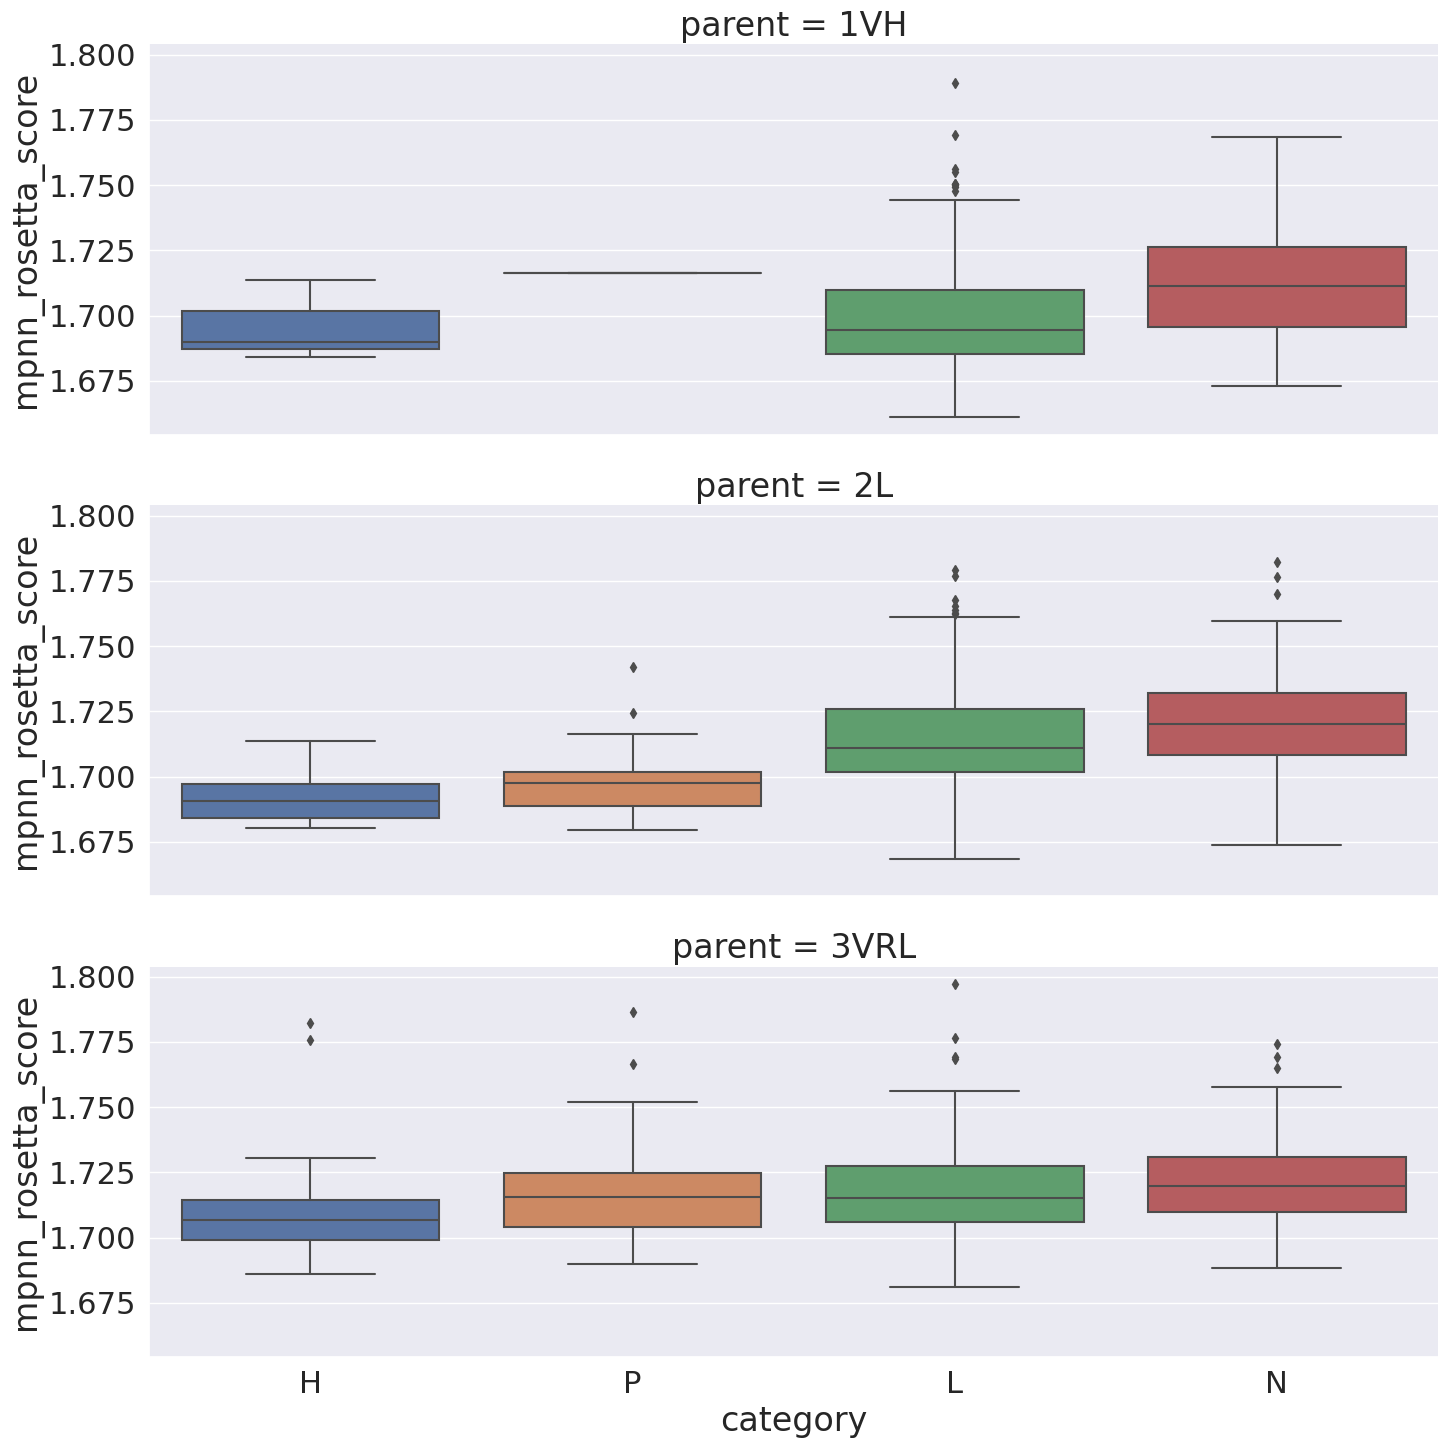

In [9]:
sns.set(font_scale = 2)

g = sns.catplot(x='category', y='mpnn_rosetta_score', row="parent", data=df_all, kind="box", aspect=3)
g.fig.savefig("../output/mpnn_score_on_screening_data.png", dpi=300)


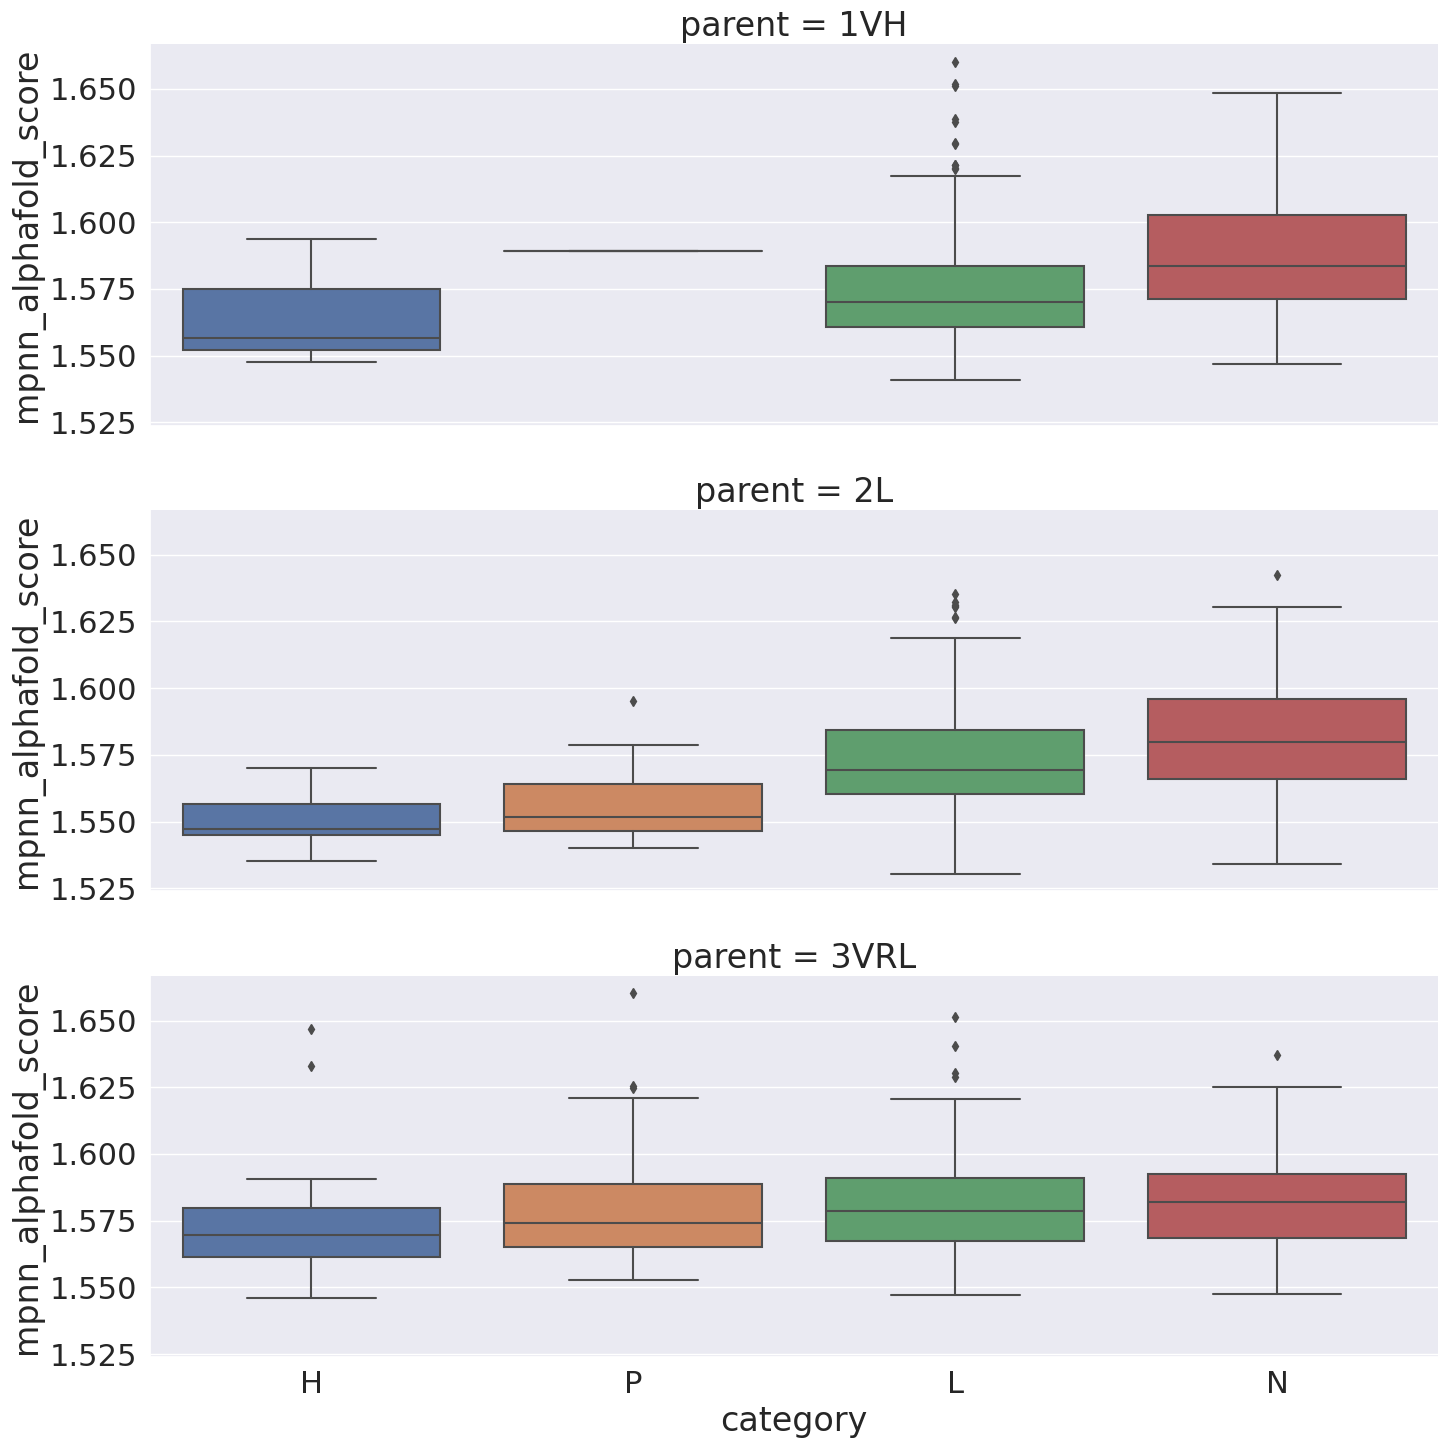

In [10]:
sns.set(font_scale = 2)

g = sns.catplot(x='category', y='mpnn_alphafold_score', row="parent", data=df_all, kind="box", aspect=3)
g.fig.savefig("../output/mpnn_score_on_screening_data.png", dpi=300)

In [11]:
def f(x):
    d = {}

    sr = scipy.stats.spearmanr(-x.response, x.mpnn_rosetta_score)
    d['mpnn_rosetta_score_spearman'] = sr.statistic
    d['mpnn_rosetta_score_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.mpnn_rosetta_score)
    d['mpnn_rosetta_score_kendalltau'] = sk.statistic
    d['mpnn_rosetta_score_kendalltau_p'] = sr.pvalue

    sr = scipy.stats.spearmanr(-x.response, x.mpnn_alphafold_score)
    d['mpnn_alphafold_score_spearman'] = sr.statistic
    d['mpnn_alphafold_score_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.mpnn_alphafold_score)
    d['mpnn_alphafold_score_kendalltau'] = sk.statistic
    d['mpnn_alphafold_score_kendalltau_p'] = sr.pvalue
    
    sr = scipy.stats.spearmanr(-x.response, x.dca_score)
    d['dca_score_spearman'] = sr.statistic
    d['dca_score_spearman_p'] = sr.pvalue
    sk = scipy.stats.kendalltau(-x.response, x.dca_score)
    d['dca_score_kendalltau'] = sk.statistic
    d['dca_score_kendalltau_p'] = sr.pvalue
    
    

    d['N'] = len(x)
    return pd.Series(d, index=['mpnn_rosetta_score_spearman', 'mpnn_rosetta_score_spearman_p', 
                               'mpnn_rosetta_score_kendalltau', 'mpnn_rosetta_score_kendalltau_p', 
                               'mpnn_alphafold_score_spearman', 'mpnn_alphafold_score_spearman_p', 
                               'mpnn_alphafold_score_kendalltau', 'mpnn_alphafold_score_kendalltau_p', 
                               'dca_score_spearman', 'dca_score_spearman_p', 
                               'dca_score_kendalltau', 'dca_score_kendalltau_p',
                               'N'])


parent_aa_dist_stats = df_all.groupby(["parent", "aa_dist"]).apply(f)
parent_aa_dist_stats

mpnn_rosetta_score_spearman  mpnn_rosetta_score_spearman_p  \
parent aa_dist                                                               
1VH    1                           0.232150                       0.016638   
       2                           0.064982                       0.502019   
       3                           0.331171                       0.000866   
       4                           0.127243                       0.368695   
       5                           0.007954                       0.962734   
       6                          -0.196116                       0.501611   
       7                          -0.258199                       0.741801   
2L     1                           0.203584                       0.022776   
       2                           0.210579                       0.011296   
       3                           0.183296                       0.065178   
       4                          -0.098552                       0.457720   
       5                          -0.155260                       0.351969   
       6                          -0.230940                       0.494466   
       7                          -0.258199                       0.741801   
3VRL   1                           0.142910                       0.067076   
       2                           0.177148                       0.032433   
       3                           0.099607                       0.370288   
       4                           0.173443                       0.304605   
       5                           0.229369                       0.430223   
       6                           0.292770                       0.573392   
       7                                NaN                            NaN   
       8                                NaN                            NaN   

                mpnn_rosetta_score_kendalltau  \
parent aa_dist                                  
1VH    1                             0.189140   
       2                             0.053786   
       3                             0.268395   
       4                             0.105075   
       5                             0.006586   
       6                            -0.165748   
       7                            -0.235702   
2L     1                             0.163644   
       2                             0.171229   
       3                             0.147614   
       4                            -0.081214   
       5                            -0.128195   
       6                            -0.196946   
       7                            -0.235702   
3VRL   1                             0.111834   
       2                             0.133255   
       3                             0.080653   
       4                             0.144094   
       5                             0.174485   
       6                             0.258199   
       7                                  NaN   
       8                                  NaN   

                mpnn_rosetta_score_kendalltau_p  \
parent aa_dist                                    
1VH    1                               0.016638   
       2                               0.502019   
       3                               0.000866   
       4                               0.368695   
       5                               0.962734   
       6                               0.501611   
       7                               0.741801   
2L     1                               0.022776   
       2                               0.011296   
       3                               0.065178   
       4                               0.457720   
       5                               0.351969   
       6                               0.494466   
       7                               0.741801   
3VRL   1                               0.067076   
       2                               0.032433   
       3                               0.370288 

In [12]:
stats_to_plot = parent_aa_dist_stats[parent_aa_dist_stats.N > 50][[
    "mpnn_rosetta_score_spearman", "mpnn_rosetta_score_spearman_p",
    "mpnn_alphafold_score_spearman", "mpnn_alphafold_score_spearman_p",
   "dca_score_spearman", "dca_score_spearman_p"]]
stats_to_plot_melt = pd.melt(stats_to_plot.reset_index(), id_vars = ["parent", "aa_dist"])
stats_to_plot_melt.head()

,parent,aa_dist,variable,value
0,1VH,1,mpnn_rosetta_score_spearman,0.232150
1,1VH,2,mpnn_rosetta_score_spearman,0.064982
2,1VH,3,mpnn_rosetta_score_spearman,0.331171
3,1VH,4,mpnn_rosetta_score_spearman,0.127243
4,2L,1,mpnn_rosetta_score_spearman,0.203584


In [13]:
stats_to_plot_melt[(stats_to_plot_melt.parent == "1VH") & (stats_to_plot_melt.aa_dist == 1)]

,parent,aa_dist,variable,value
0,1VH,1,mpnn_rosetta_score_spearman,0.232150
11,1VH,1,mpnn_rosetta_score_spearman_p,0.016638
22,1VH,1,mpnn_alphafold_score_spearman,0.198285
33,1VH,1,mpnn_alphafold_score_spearman_p,0.041596
44,1VH,1,dca_score_spearman,0.264747
55,1VH,1,dca_score_spearman_p,0.006097


In [14]:
stats_to_plot_melt.variable.unique()

array(['mpnn_rosetta_score_spearman', 'mpnn_rosetta_score_spearman_p',
       'mpnn_alphafold_score_spearman', 'mpnn_alphafold_score_spearman_p',
       'dca_score_spearman', 'dca_score_spearman_p'], dtype=object)

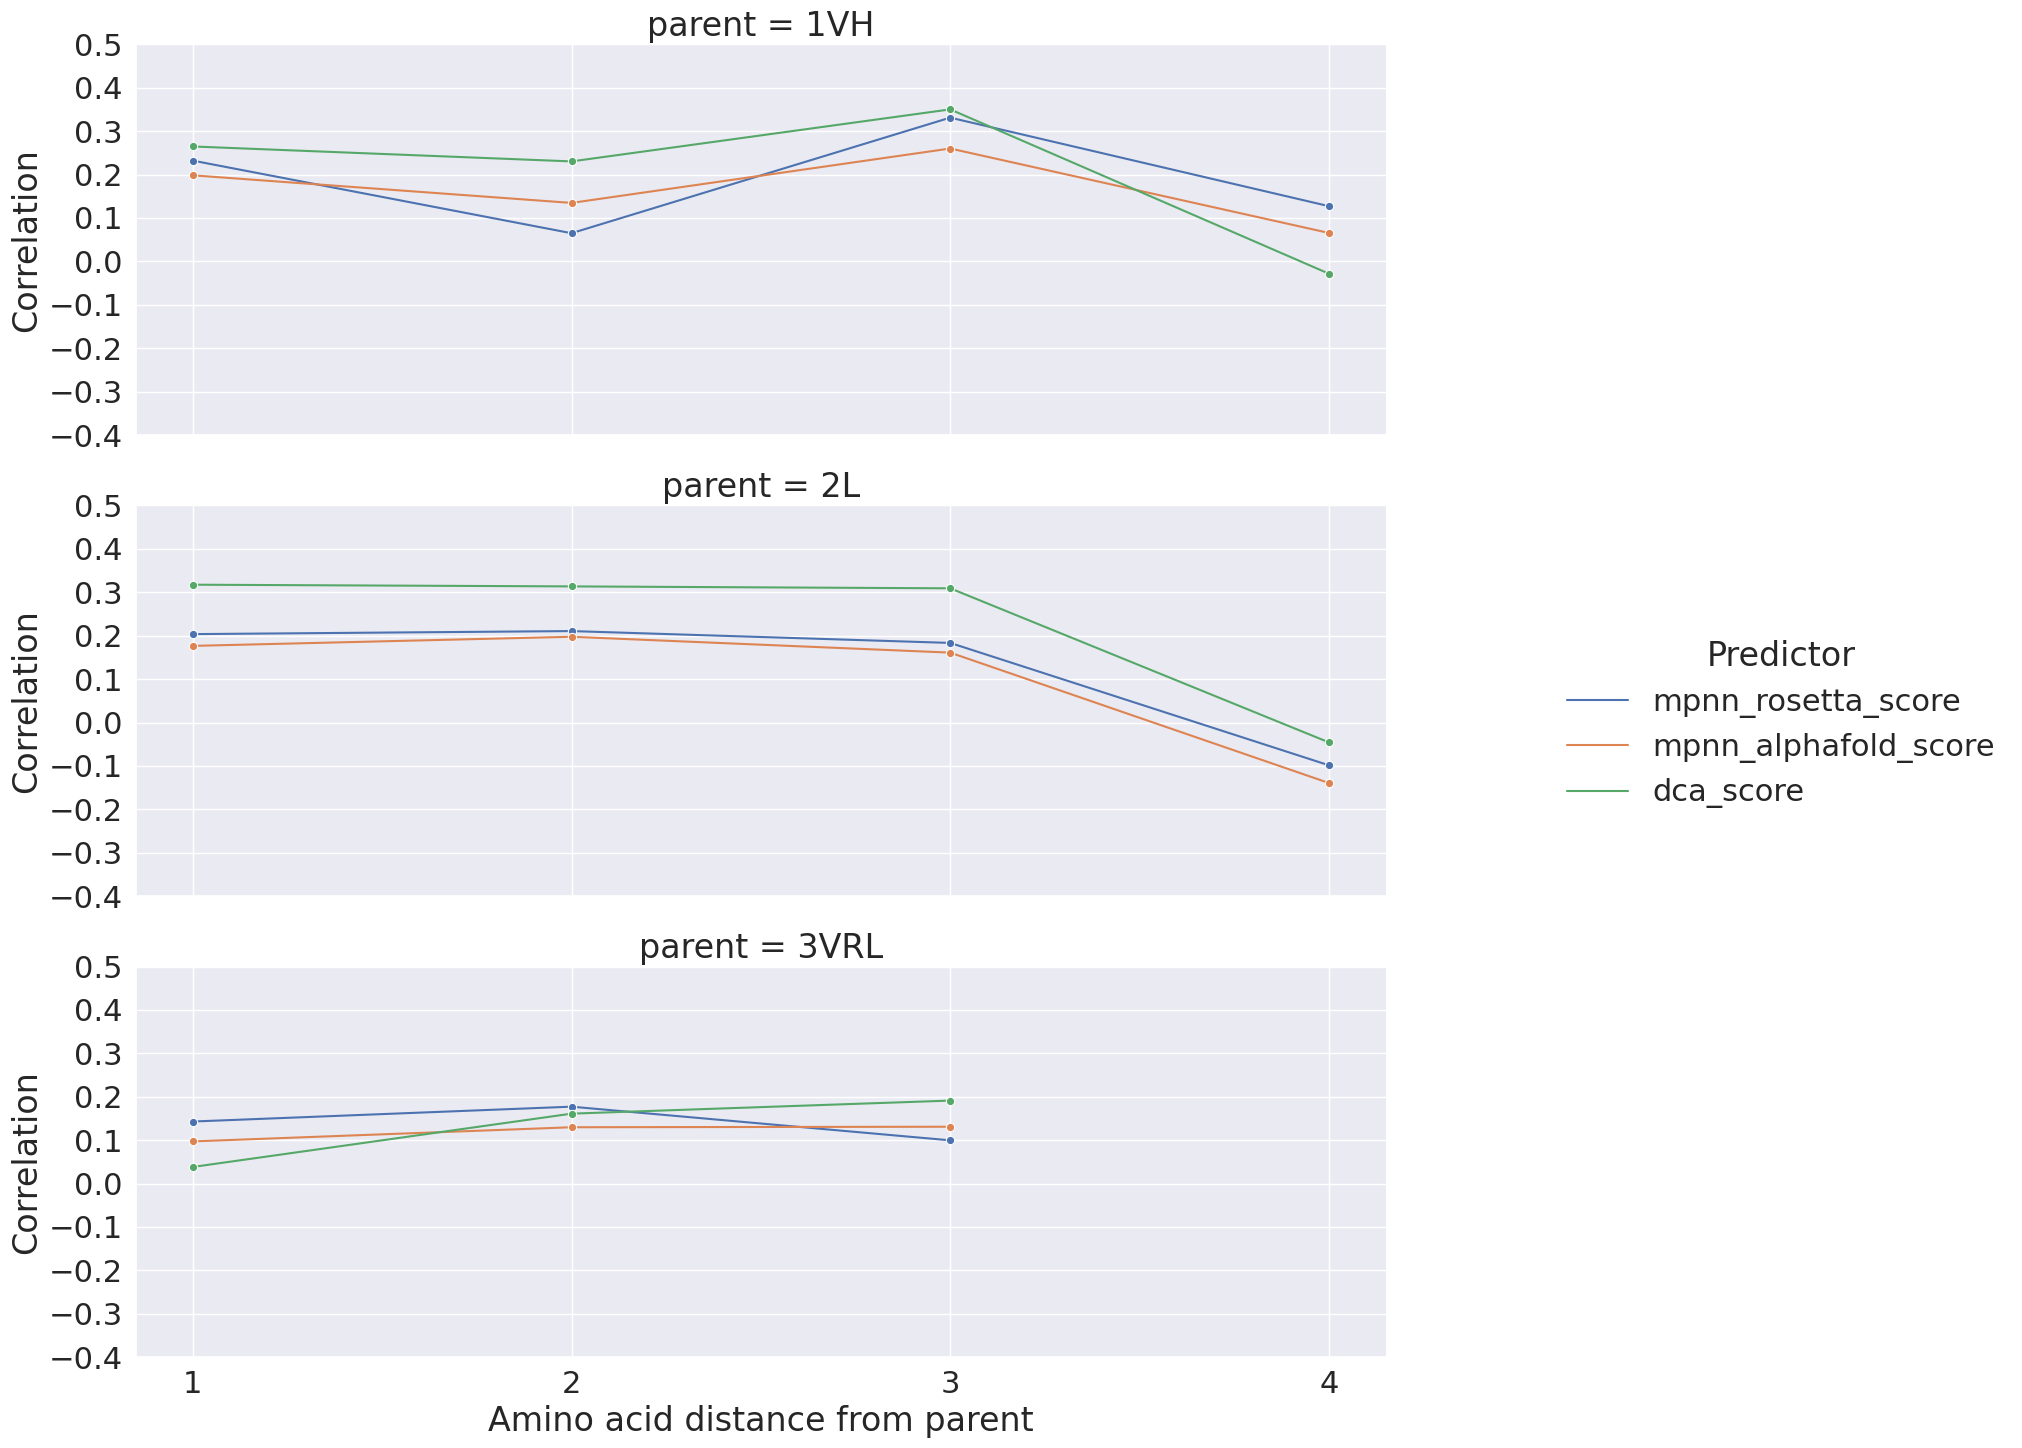

In [15]:
sns.set(font_scale=2)
g = sns.relplot(stats_to_plot_melt[~ stats_to_plot_melt.variable.str.endswith("_p")],
            x="aa_dist", y="value", row="parent", hue="variable", kind='line',
                aspect=3, marker='o')
_ = [ax.xaxis.set_major_locator(MaxNLocator(integer=True)) for ax in g.axes.flatten()]

_ = [ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1)) for ax in g.axes.flatten()]

g.set(ylabel="Correlation", ylim=(-0.4, 0.5), xlabel="Amino acid distance from parent")
g._legend.set_title("Predictor")
# replace labels
new_labels = ['mpnn_rosetta_score', 'mpnn_alphafold_score','dca_score']
for t, l in zip(g._legend.texts, new_labels):
    t.set_text(l)
    
g.fig.savefig("../output/mpnn_score_on_screening_data_mutation_adjusted.png", dpi=300)

    